<div align="center">

# <span style="color: #3498db;">CA2 - Genetic & Game</span>

**<span style="color:rgb(247, 169, 0);">[Zakiye Amin]</span> - <span style="color:rgb(143, 95, 195);">[810102398]</span>**

</div>


<div style="font-family: Arial, sans-serif; line-height: 1.6;">

### 📊 Matplotlib – Data Visualization in Python  

matplotlib is a python library that is mainly used for data visualization. This library allows you to plot different type of figures including scatters and histograms. In the first part of this project you are supposed to implement a genetic algorithm. To visualize plots that are required in the project description use plotting as much as you can because it gives a great insight on what is happening during each run. It also helps you to compare your results whenevever you want to understand effect of different parameters during different runs.
For more information, check [this notebook](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.00-Introduction-To-Matplotlib.ipynb) and visit [the website](https://matplotlib.org/stable/tutorials/pyplot.html#sphx-glr-tutorials-pyplot-py).

In [1]:
import matplotlib.pyplot as plt

# <span style="color: #3498db;">Genetic Algorithm</span>

In [2]:
import random
import itertools
import numpy as np
import math

In [3]:
# algorithm parameters
numCoeffs = 41
populationSize = 100
generations = 50
mutationRate = 0.05
functionRange = (-np.pi, np.pi)
sampleCount = 100

In [4]:
# These functions are given as samples to use in the algorithm
def getTargetFunction(functionName):
    def sinCosFunction(t):
        """Target function: sin(2πt) + 0.5*cos(4πt)."""
        return np.sin(2 * np.pi * t) + 0.5 * np.cos(4 * np.pi * t)

    def linearFunction(t):
        """Simple linear function: y = 2t + 1."""
        return 2 * t + 1

    def quadraticFunction(t):
        """Quadratic function: y = 4t^2 - 4t + 2."""
        return 4 * (t**2) - 4 * t + 2

    def cubicFunction(t):
        """Cubic function: y = 8t^3 - 12t^2 + 6t."""
        return 8 * (t**3) - 12 * (t**2) + 6 * t

    def gaussianFunction(t):
        """Gaussian function centered at t=0.5."""
        mu = 0.5
        sigma = 0.1  # Adjust sigma to control the width of the peak
        return np.exp(-((t - mu) ** 2) / (2 * sigma**2))

    def squareWaveFunction(t):
        """Approximation of a square wave. Smoothed for better Fourier approximation."""
        return 0.5 * (np.sign(np.sin(2 * np.pi * t)) + 1)

    def sawtoothFunction(t):
        """Sawtooth wave, normalized to [0, 1]."""
        return (t * 5) % 1

    def complexFourierFunction(t):
        return (
            np.sin(2 * np.pi * t)
            + 0.3 * np.cos(4 * np.pi * t)
            + 0.2 * np.sin(6 * np.pi * t)
            + 0.1 * np.cos(8 * np.pi * t)
        )

    def polynomialFunction(t):
        return 10 * (t**5) - 20 * (t**4) + 15 * (t**3) - 4 * (t**2) + t + 0.5

    functionOptions = {
        "sin_cos": sinCosFunction,
        "linear": linearFunction,
        "quadratic": quadraticFunction,
        "cubic": cubicFunction,
        "gaussian": gaussianFunction,
        "square_wave": squareWaveFunction,
        "sawtooth": sawtoothFunction,
        "complex_fourier": complexFourierFunction,
        "polynomial": polynomialFunction,
    }

    selectedFunction = functionOptions.get(functionName.lower())
    if selectedFunction:
        return selectedFunction

In [5]:
# generate samples
tSamples = np.linspace(functionRange[0], functionRange[1], sampleCount)
fSamples = getTargetFunction("sin_cos")(tSamples)

<div style="color:rgb(235, 66, 32); font-weight: bold;">⚠️ Important Note:</div>  

Using **NumPy arrays** allows you to perform operations on vectors **more efficiently** and **faster**.

**Avoid using `for` loops** whenever possible, as vectorized operations in NumPy are **optimized for performance** and significantly reduce execution time.  


***Generate First Generation Randomly***

In [6]:
def GenerateFirstGeneration(fSamples):
    ValueRange = np.max(np.abs(fSamples))
    FirstGeneration = []
    for i in range (100):
        chromosome = []
        for j in range(41):
            chromosome.append(random.uniform(-ValueRange, ValueRange))
        FirstGeneration.append(chromosome)
    return FirstGeneration

***Different Fitness Functions***

In [7]:
def CalculateFourierSeries(tSamples, chromosome):
    n = (len(chromosome) - 1) // 2
    a_0 = chromosome[0] / 2
    approx = a_0 * np.ones_like(tSamples)
    for i in range(1, n+1):
        a_n = chromosome[2 * i - 1]
        b_n = chromosome[2 * i]
        approx += a_n * np.cos(i * tSamples) + b_n * np.sin(i * tSamples)
    return approx

In [8]:
def CalculateFitnessRMSE(tSamples, fSamples, chromosome):
    approx = CalculateFourierSeries(tSamples, chromosome)
    mse = 0
    for i in range(len(fSamples)):
        mse += (fSamples[i] - approx[i])**2
    rmse = math.sqrt(mse / len(fSamples))
    return rmse

def CalculateFitnessMAE(tSamples, fSamples, chromosome):
    approx = CalculateFourierSeries(tSamples, chromosome)
    mae = np.mean(np.abs(fSamples - approx))
    return mae
    
def CalculateFitnessMSE(tSamples, fSamples, chromosome):
    approx = CalculateFourierSeries(tSamples, chromosome)
    mse = 0
    for i in range(len(fSamples)):
        mse += (fSamples[i] - approx[i])**2
    mse = math.sqrt(mse / len(fSamples))
    return mse

***Different Type Of Crossovers***

In [9]:
def OnePointCrossover(FirstParent, SecondParent, CrossoverRate = 0.5):
    CrossoverProbability = random.random()
    if  CrossoverProbability < CrossoverRate:
        return FirstParent, SecondParent
    CrossoverPoint = random.randint(1, numCoeffs-1)
    FirstChild =  FirstParent[0:CrossoverPoint] + SecondParent[CrossoverPoint:]
    SecondChild = SecondParent[0:CrossoverPoint] + FirstParent[CrossoverPoint:]
    return FirstChild, SecondChild

def NPointCrossover(FirstParent, SecondParent, CrossoverRate = 0.5, n = 3):
    CrossoverProbability = random.random()
    if  CrossoverProbability < CrossoverRate:
        return FirstParent, SecondParent
    RandomPoint = sorted(np.random.randint(1, numCoeffs - 1, size=n))
    points = [0] + RandomPoint + [numCoeffs]
    FirstChild = []
    SecondChild = []
    for i in range(len(points) - 1):
        start, end = points[i], points[i + 1]
        if i % 2 == 0:
            FirstChild += FirstParent[start:end]
            SecondChild += SecondParent[start:end]
        else:
            FirstChild += SecondParent[start:end]
            SecondChild += FirstParent[start:end]
    return FirstChild, SecondChild

def UniformCrossover(FirstParent, SecondParent, CrossoverRate = 0.5):
    CrossoverProbability = random.random()
    if  CrossoverProbability < CrossoverRate:
        return FirstParent, SecondParent
    FirstChild = []
    SecondChild = []
    for i in range(len(FirstParent)):
        probability = random.random()
        if probability <= 0.5 :
            FirstChild.append(FirstParent[i])
            SecondChild.append(SecondParent[i])
        else:
            FirstChild.append(SecondParent[i])
            SecondChild.append(FirstParent[i])
    return FirstChild, SecondChild


***Mutation***

In [10]:

def MutateChromosome(mutationRate, chromosome):
    MaxValue = np.max(np.abs(fSamples))
    for i in range(len(chromosome)):
        probability = random.random()
        if probability <= mutationRate:
            chromosome[i] += (np.random.uniform(-0.1, 0.1) * MaxValue)
    return chromosome

***Selection Functions***

In [11]:
def RankChromosome(population):
    total = (len(population) * (len(population)+1)) / 2
    CoefficientRank = []
    for i in range(len(population)):
        CoefficientRank.append((len(population)-i) / total)
    return CoefficientRank

def RankingSelection(population, FitnessScores):
    CoefficientRank = RankChromosome(population)
    index = np.arange(len(population))
    SelectedIndex = np.random.choice(index, p=CoefficientRank)
    return population[SelectedIndex]

def TournamentSelection(population, FitnessScores):
    SelectedIndices = np.random.choice(np.arange(0, len(population)), size = 4, replace = False)
    MinIndex = np.min(SelectedIndices)
    return population[MinIndex]

def RouletteWheelSelection(population, FitnessScores):
    InverseFitness = [1 / score if score != 0 else 1e6 for score in FitnessScores]
    total = sum(InverseFitness)
    probability = [score / total for score in InverseFitness]
    SelectedIndices = np.random.choice(np.arange(0, len(population)), size = 1, replace = False, p = probability)[0]
    return population[SelectedIndices]


In [12]:
def GeneticAlgorithm(FitnessMethod, SelectionMethod, CrossoverMethod, GenerationStep=300):
    population = GenerateFirstGeneration(fSamples)
    for step in range(GenerationStep):
        FitnessScores = [FitnessMethod(tSamples, fSamples, chromosome) for chromosome in population]
        sorted_indices = np.argsort(FitnessScores)
        FitnessScores = [FitnessScores[i] for i in sorted_indices]
        population = [population[i] for i in sorted_indices]
        elite = population[:10] 
        NextGeneration = elite[:]
        while len(NextGeneration) < sampleCount:
            FirstParent = SelectionMethod(population, FitnessScores)
            SecondParent = SelectionMethod(population,FitnessScores)
            FirstChild, SecondChild = CrossoverMethod(FirstParent, SecondParent)
            FirstChild = MutateChromosome(mutationRate, FirstChild)
            SecondChild = MutateChromosome(mutationRate, SecondChild)
            NextGeneration.append(FirstChild)
            if len(NextGeneration) < sampleCount:
                NextGeneration.append(SecondChild)
        population = NextGeneration
    return population


***Show Plots For different selections, fitness functions and crossovers***

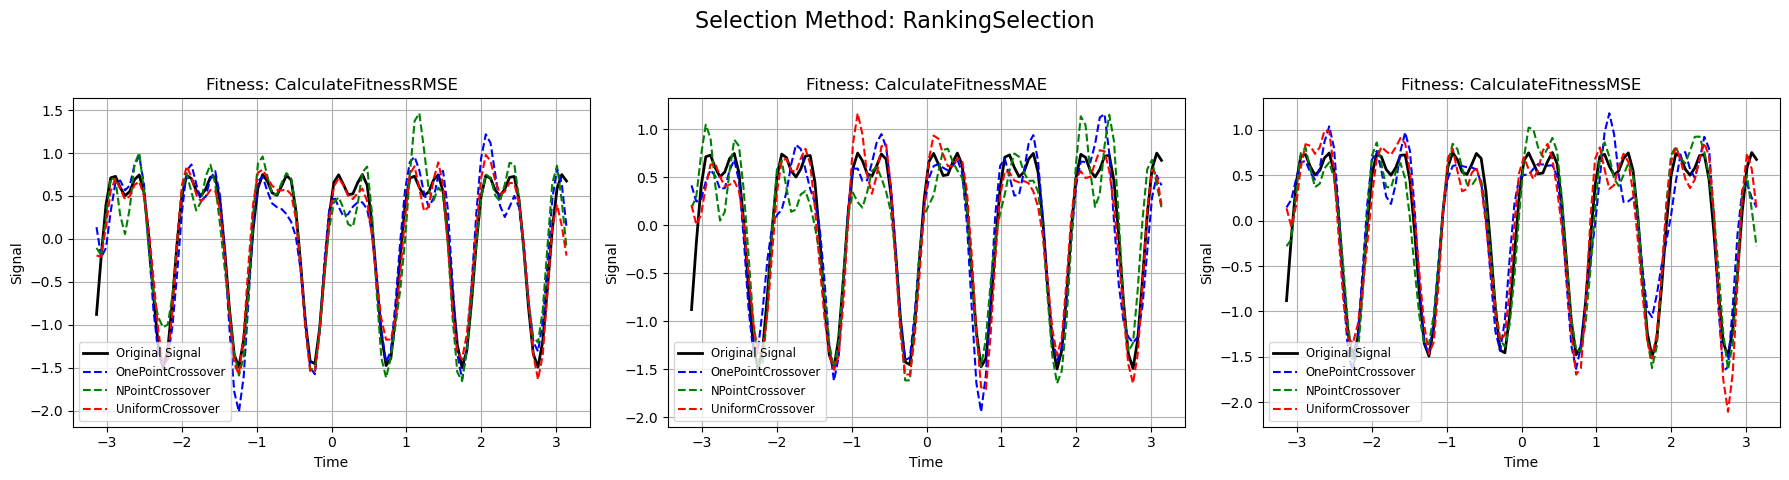

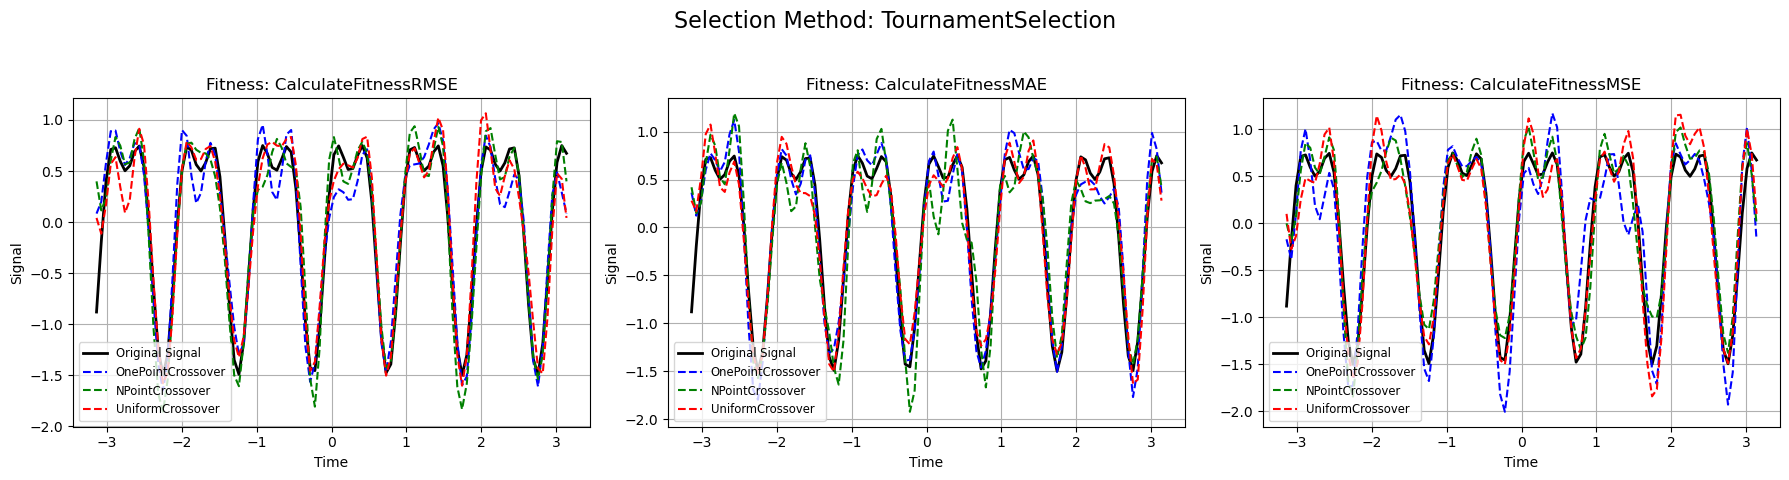

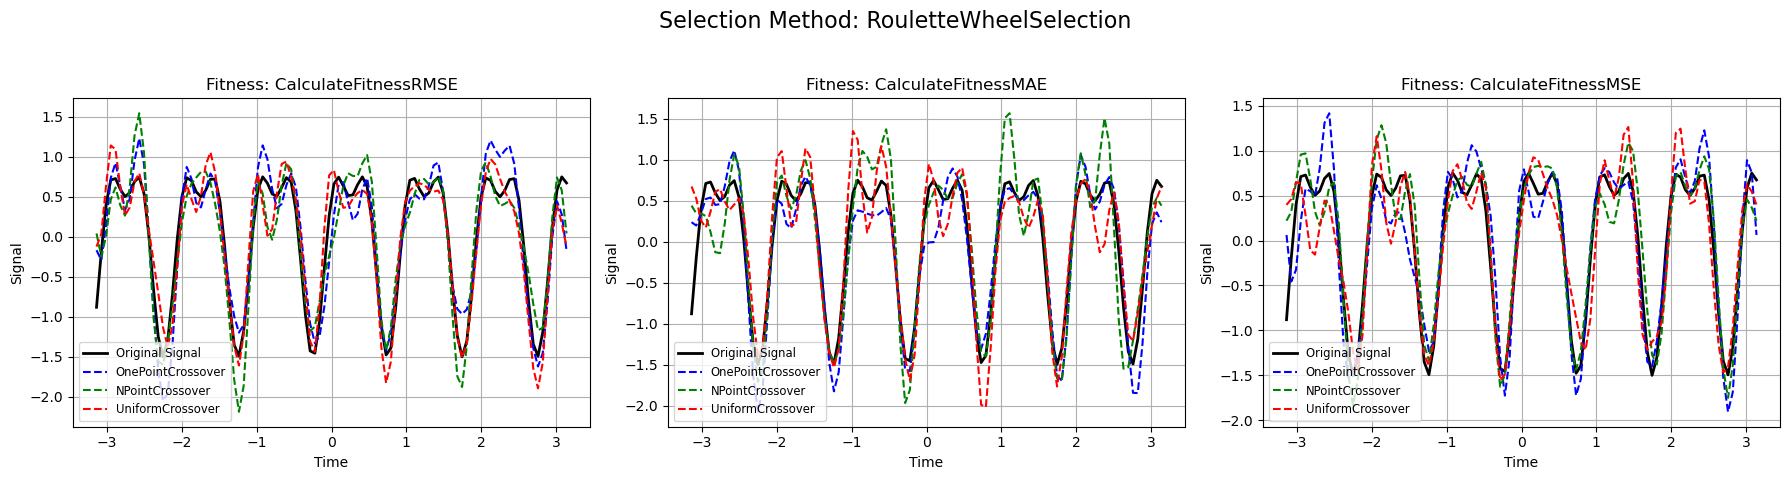

In [13]:
SelectionMethods = [RankingSelection, TournamentSelection, RouletteWheelSelection]
FitnessMethod = [CalculateFitnessRMSE, CalculateFitnessMAE, CalculateFitnessMSE]
CrossoverMethod = [OnePointCrossover, NPointCrossover, UniformCrossover]


crossover_colors = {"OnePointCrossover": "blue", "NPointCrossover": "green","UniformCrossover": "red"}

for sel_method in SelectionMethods:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5)) 
    fig.suptitle(f"Selection Method: {sel_method.__name__}", fontsize=16)
    for idx, fit_method in enumerate(FitnessMethod):
        ax = axs[idx]
        ax.plot(tSamples, fSamples, label='Original Signal', linewidth=2, color='black')
        for cross_method in CrossoverMethod:
            population = GeneticAlgorithm(FitnessMethod=fit_method, SelectionMethod=sel_method, CrossoverMethod=cross_method)
            best_chromosome = population[0]
            approximation = CalculateFourierSeries(tSamples, best_chromosome)
            ax.plot(tSamples, approximation, label=cross_method.__name__, color=crossover_colors[cross_method.__name__], linestyle='--')
        ax.set_title(f"Fitness: {fit_method.__name__}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Signal")
        ax.grid(True)
        ax.legend(fontsize='small')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.show()


***Question 1***

Each chromosome represents one possible solution and consists of 41 genes.

If each coefficient is allowed to vary within a range of [−A , A] and you assume a resolution or step size of 0.01, the number of possible values for each gene is:
Number of values per gene = 200A + 1

So the total size of the chromosomal state space is: (200A + 1) ^ 41 which is a huge search space.

---

***Question 2***

    Preserving the Best Individuals:

This technique involves carrying over a small portion of the top-performing chromosomes (top 5% or 10%) unchanged into the next generation. It ensures that the best solutions found so far are not lost during crossover or mutation.

    Rank-Based Selection
Instead of picking based on raw fitness, assign selection probabilities based on rank in the population. This avoids dominant individuals taking over too soon and encourages steady improvement.

---

***Question 3***

    Generational Replacement
The entire previous generation is discarded, and the next generation is formed entirely from newly generated through crossover and mutation.

➕ Advantages:

High genetic diversity in each new generation

Rapid population change, which can accelerate exploration

➖ Disadvantages:

Good solutions may be lost from one generation to the next

    Preserving the Best Individuals
In this strategy, a small number of the best-performing chromosomes from the current generation are copied directly into the next generation without any changes. The rest of the population is created through crossover and mutation.

➕ Advantages:

Guarantees that the best solutions are not lost.

Improves convergence speed and stability.

➖ Disadvantages:

If elitism is too strong, diversity can drop, and the algorithm may converge prematurely to a local optimum.


    teady-State Selection 
In steady-state selection, only a few individuals are replaced at a time.

For example, a pair of parents produce 2 children. These children are then inserted into the population, replacing either the worst individuals or specific parents—sometimes only if they're better.

➕ Advantages:

Maintains genetic diversity better over time.

Offers more stability and reduces the chance of premature convergence.

Works well for problems with complex or sensitive fitness landscapes.

➖ Disadvantages:

Slower convergence compared to full replacement.



---

***Question 4***

     Increasing Mutation Rate
Mutations introduce random changes to an individual's genetic structure, potentially bringing new features into the population. If the mutation rate is too low, the population might converge to a local optimum without exploring other potential solutions. By increasing the mutation rate, the algorithm is more likely to explore a larger solution space, helping to avoid local optima and encouraging the algorithm to continue searching for better solutions.   

    Tournament Selection 
If the tournament size is kept small, tournament selection can help maintain diversity because it increases the chances that individuals with different fitness levels can still be selected. This allows less-fit individuals to have a chance to survive and reproduce, which can keep the population diverse.

---

***Question 5***

The R-squared function measures the proportion of the variance in the dependent variable that is explained by the model. It is calculated as:
$$
R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}
$$

$y_i$
​
  = Target values.

$\hat{y}_i$ = Predicted values by the model.

$\bar{y}$ = Mean of the actual values.

$𝑁$ = is the number of data points.

-If $𝑅^2 = 1$:

The model explains all the variance in the data (perfect fit).

-If $𝑅^2 = 0$:

It performs no better than predicting the mean of the target values.

R-squared can be useful in our project. In fact, R-squared is a common metric for evaluating regression models, and since predicting Fourier coefficients is essentially a regression problem, it can serve as an effective tool to calculate how well the GA is fitting the Fourier coefficients to the target data.

# <span style="color: #3498db;">Minmax Algorithm</span>

In [14]:
!pip install pygame

In [15]:
import random
import numpy as np
from math import inf
import time
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.12.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [16]:
def score_line(line):
            AI_count = 0
            human_count = 0
            empty_count = 0
            for val in line:
                if val == -1:
                    AI_count += 1
                elif val == 1:
                    human_count += 1
                else:
                    empty_count += 1
            if human_count > 0 and AI_count > 0:
                return 0  
            if AI_count > 0 and human_count == 0:
                if AI_count == 5:
                    return 1000
                elif AI_count == 4:
                    return 100
                elif AI_count == 3:
                    return 10
                elif AI_count == 2:
                    return 3
            elif human_count > 0:
                if human_count == 5 and human_count == 0:
                    return -1000
                elif human_count == 4:
                    return -100
                elif human_count == 3:
                    return -10
                elif human_count == 2:
                    return -3
            return 0

In [32]:
class PentagoGame:
    def __init__(self, ui=False, print=False, depth=2):
        self.board = np.zeros((6, 6), dtype=int)
        self.current_player = 1
        self.ui = ui
        self.depth = depth
        self.nodes_visited = 0
        self.game_over = False
        self.result = None
        self.selected_block = None
        self.move_stage = 0  # 0: place piece, 1: select block, 2: rotate
        self.temp_piece = None
        self.print = print

        if ui:
            pygame.font.init()
            self.screen = pygame.display.set_mode((800, 600))
            pygame.display.set_caption("Pygame Board")
            # self.font = pygame.font.SysFont("Arial", 20)
            self.show_buttons = False
            self.buttons = {
                "rotate_cw": pygame.Rect(650, 200, 100, 50),
                "rotate_ccw": pygame.Rect(650, 300, 100, 50),
            }
            self.setup_controls()
            self.draw_board()

    def setup_controls(self):
        if self.show_buttons:
            pygame.draw.rect(self.screen, (144, 238, 144), self.buttons["rotate_cw"])   # Light Green
            pygame.draw.rect(self.screen, (173, 216, 230), self.buttons["rotate_ccw"])  # Light Blue

            self.screen.draw_text("CLOCKWISE", self.buttons["rotate_cw"].center)
            self.screen.draw_text("COUNTER-CLOCKWISE", self.buttons["rotate_ccw"].center)

    def hide_rotation_buttons(self):
        self.show_buttons = False

    def show_rotation_buttons(self):
        self.show_buttons = True

    def copy_board(self, board):
        return np.copy(board)

    def rotate_block(self, board, block, direction):
        row_start = (block // 2) * 3
        col_start = (block % 2) * 3
        sub = board[row_start : row_start + 3, col_start : col_start + 3]
        rotated = np.rot90(sub, 3 if direction == "cw" else 1)
        board[row_start : row_start + 3, col_start : col_start + 3] = rotated

    def get_possible_moves(self, board, player):
        moves = []
        for i in range(6):
            for j in range(6):
                if board[i][j] == 0:
                    for block in range(4):
                        for dir in ["cw", "ccw"]:
                            moves.append((i, j, block, dir))
        return moves

    def apply_move(self, board, move, player):
        new_board = self.copy_board(board)
        row, col, block, direction = move
        if new_board[row][col] != 0:
            return None
        new_board[row][col] = player
        self.rotate_block(new_board, block, direction)
        return new_board

    def check_winner(self, board):
        for i in range(6):
            for j in range(6):
                if board[i][j] == 0:
                    continue

                # Horizontal
                if j <= 1 and np.all(board[i, j : j + 5] == board[i][j]):
                    return board[i][j]

                # Vertical
                if i <= 1 and np.all(board[i : i + 5, j] == board[i][j]):
                    return board[i][j]

                # Diagonal
                if (
                    i <= 1
                    and j <= 1
                    and all(board[i + k][j + k] == board[i][j] for k in range(5))
                ):
                    return board[i][j]

                # Anti-diagonal
                if (
                    i <= 1
                    and j >= 4
                    and all(board[i + k][j - k] == board[i][j] for k in range(5))
                ):
                    return board[i][j]
        if np.all(board != 0):
            return 0
        return None

    def hueristic_function(self, board):
        score = 0
        for i in range(6):
            for j in range(2): 
                row = board[i, j:j+5]
                col = board[j:j+5, i]
                score += score_line(row)
                score += score_line(col)
        for i in range(2):
            for j in range(2):
                diag = [board[i+k][j+k] for k in range(5)]
                anti = [board[i+k][j+4-k] for k in range(5)]
                score += score_line(diag)
                score += score_line(anti)
        return score


    def minimax(self, board, depth, maximizing_player):
        if self.game_over:
            return 0
        self.nodes_visited += 1
        if depth == 0:
            return self.hueristic_function(board)
        
        if maximizing_player:
            maximum = -float('inf')
            for move in self.get_possible_moves(board, -1):  
                new_board = self.apply_move(board, move, -1)
                if new_board is None:
                    continue
                new_evaluation = self.minimax(new_board, depth - 1, False)
                maximum = max(maximum, new_evaluation)
            return maximum
        else:
            minimum = float('inf')
            for move in self.get_possible_moves(board, 1):  
                new_board = self.apply_move(board, move, 1)
                if new_board is None:
                    continue
                new_evaluation = self.minimax(new_board, depth - 1, True)
                minimum = min(minimum, new_evaluation)
            return minimum
    

    def minimax_alphabeta(self, board, depth, alpha, beta, maximizing_player):
        if self.game_over:
            return 0
        self.nodes_visited += 1
        if depth == 0:
            return self.hueristic_function(board)
        if maximizing_player:
            maximum = -float('inf')
            for move in self.get_possible_moves(board, -1):
                new_board = self.apply_move(board, move, -1)
                if new_board is None:
                    continue
                new_evaluation = self.minimax_alphabeta(new_board, depth - 1,alpha, beta, False)
                maximum = max(maximum, new_evaluation)
                alpha = max(alpha, new_evaluation)
                if alpha >= beta:
                    break
            return maximum
        else:
            minimum = float('inf')
            for move in self.get_possible_moves(board, 1):
                new_board = self.apply_move(board, move, 1)
                if new_board is None:
                    continue
                new_evaluation = self.minimax_alphabeta(new_board, depth - 1, alpha, beta, True)
                minimum = min(minimum, new_evaluation)
                beta = min(beta, new_evaluation)
                if alpha >= beta:
                        break
            return minimum

    def get_computer_move(self):
        start_time = time.time()
        best_move = None
        best_value = -inf
        alpha =  -float("inf")
        beta =  float("inf")
        moves = self.get_possible_moves(self.board, -1)
        if not moves:
            return None
        best_move = moves[0]

        for move in moves:
            if self.game_over:
                break
            new_board = self.apply_move(self.board, move, -1)
            if new_board is None:
                continue

            try:
                #value = self.minimax(new_board, self.depth-1, False)
                value = self.minimax_alphabeta(new_board, self.depth-1, alpha, beta, False)
                alpha = max(alpha, value)
                #TODO: Implement alpha-beta pruning algorithm
            except:
                value = -inf

            if value > best_value:
                best_value = value
                best_move = move

        if self.print == True:
            print(f"Move took {time.time()-start_time:.2f}s, nodes visited: {self.nodes_visited}")
        self.nodes_visited = 0
        return best_move

    def draw_text(self, text, center_pos, max_width):
        font_size = 24
        font = pygame.font.Font(None, font_size)
        text_surface = font.render(text, True, (0, 0, 0))

        text_width = text_surface.get_width()
        if text_width > max_width:
            scale_factor = max_width / text_width
            new_font_size = int(font_size * scale_factor)
            font = pygame.font.Font(None, new_font_size)
            text_surface = font.render(text, True, (0, 0, 0))

        text_rect = text_surface.get_rect(center=center_pos)
        self.screen.blit(text_surface, text_rect)

    def draw_board(self):
        self.screen.fill((0, 0, 0))

        for i in range(6):
            for j in range(6):
                x0 = j * 100
                y0 = i * 100

                if self.board[i][j] == 1:
                    pygame.draw.circle(self.screen, (255, 0, 0), (x0 + 50, y0 + 50), 40)
                elif self.board[i][j] == -1:
                    pygame.draw.circle(self.screen, (0, 0, 255), (x0 + 50, y0 + 50), 40)

                pygame.draw.rect(self.screen, (255, 255, 255), (x0, y0, 100, 100), 1)

        for i in [3, 6]:
            pygame.draw.line(self.screen, (255, 255, 255), (0, i * 100), (600, i * 100), 3)  # Horizontal
            pygame.draw.line(self.screen, (255, 255, 255), (i * 100, 0), (i * 100, 600), 3)  # Vertical

        # Show rotation buttons if in move_stage 2
        if self.move_stage == 2:
            self.highlight_selected_block()
            self.show_rotation_buttons()

        if self.show_buttons:
            pygame.draw.rect(self.screen, (144, 238, 144), self.buttons["rotate_cw"])  # Light Green
            pygame.draw.rect(self.screen, (173, 216, 230), self.buttons["rotate_ccw"])  # Light Blue

            self.draw_text(
                "CLOCKWISE",
                self.buttons["rotate_cw"].center,
                self.buttons["rotate_cw"].width,
            )
            self.draw_text(
                "COUNTER-CLOCKWISE",
                self.buttons["rotate_ccw"].center,
                self.buttons["rotate_ccw"].width,
            )

    def click_handler(self, event):
        if self.game_over or self.current_player != 1:
            return

        x, y = event.pos
        if self.move_stage == 0:  # Place piece
            if x > 600:
                return  # clicks on control area
            col = x // 100
            row = y // 100
            if 0 <= row < 6 and 0 <= col < 6 and self.board[row][col] == 0:
                self.temp_piece = (row, col)
                self.board[row][col] = 1
                self.move_stage = 1
                self.draw_board()

        elif self.move_stage == 1:  # Select block
            if x > 600:
                return
            # which block was clicked
            block_x = 0 if x < 300 else 1
            block_y = 0 if y < 300 else 1
            self.selected_block = block_y * 2 + block_x
            self.move_stage = 2
            self.show_rotation_buttons()
            self.highlight_selected_block()

        elif self.move_stage == 2:  # Rotate
            if self.buttons["rotate_cw"].collidepoint(event.pos):
                self.apply_rotation("cw")
            if self.buttons["rotate_ccw"].collidepoint(event.pos):
                self.apply_rotation("ccw")

    def apply_rotation(self, direction):
        self.rotate_block(self.board, self.selected_block, direction)
        self.current_player = -1
        self.move_stage = 0
        self.selected_block = None
        self.temp_piece = None
        self.hide_rotation_buttons()
        self.draw_board()
        pygame.display.flip()
        self.check_game_over()
        pygame.time.delay(1000)
        self.play_computer_move()

    def highlight_selected_block(self):
        colors = [
            (255, 153, 153),
            (153, 255, 153),
            (153, 153, 255),
            (255, 255, 153),
        ]  # RGB colors

        row_start = (self.selected_block // 2) * 3
        col_start = (self.selected_block % 2) * 3

        pygame.draw.rect(
            self.screen,
            colors[self.selected_block],
            (col_start * 100, row_start * 100, 300, 300),
            5,
        )

    def play_computer_move(self):
        move = self.get_computer_move()
        if move and not self.game_over:
            new_board = self.apply_move(self.board, move, -1)
            if new_board is not None:
                self.board = new_board
                self.current_player = 1
                self.draw_board()
                pygame.display.flip()
                self.check_game_over()
            else:
                print("Invalid computer move!")

    def check_game_over(self):
        winner = self.check_winner(self.board)
        if winner is not None:
            self.game_over = True
            self.result = winner
            print("Game over! Result:", winner)
            if self.ui:
                self.show_game_over_message()

    def show_game_over_message(self):
        self.screen.fill((200, 200, 200))
        pygame.draw.rect(self.screen, (255, 255, 255), (100, 200, 500, 200))
        pygame.draw.rect(self.screen, (0, 0, 0), (100, 200, 500, 200), 3)

        result_text = f"Player {self.result} wins!" if self.result != 0 else "Draw!"
        text_surface = self.font_large.render(result_text, True, (255, 0, 0))
        self.screen.blit(text_surface, (250, 250))

        exit_text = self.font_small.render("Click anywhere to exit", True, (0, 0, 0))
        self.screen.blit(exit_text, (230, 350))
        pygame.display.flip()

    def play(self):
        if self.ui:
            running = True
            while running:
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        running = False
                    elif event.type == pygame.MOUSEBUTTONDOWN:
                        self.click_handler(event)
                self.draw_board()
                pygame.display.flip()
            pygame.quit()
            return self.result
        else:
            while not self.game_over:
                self.print_board()
                winner = self.check_winner(self.board)
                if winner is not None:
                    return winner

                if self.current_player == 1:
                    move = random.choice(self.get_possible_moves(self.board, 1))
                else:
                    move = self.get_computer_move()

                self.board = self.apply_move(self.board, move, self.current_player)
                self.current_player *= -1
            return self.result

    def print_board(self):
        if self.print == False:
            return
        print("-" * 25)
        for row in self.board:
            print(" ".join(f"{x:2}" for x in row))
        print("-" * 25)

In [33]:
numGames = 100
numWins, numTies, numLosses = 0, 0, 0
for i in range(numGames):
    game = PentagoGame(ui=False, print=False, depth=2)  # depth=2 for faster
    result = game.play()
    if result == -1:
        numWins += 1
    elif result == 0:
        numTies += 1
    else:
        numLosses += 1

print(f"{numWins} wins, {numTies} ties, {numLosses} losses")

95 wins, 0 ties, 5 losses


***Question 1***

***Time:***

As the depth increases, the number of game states the algorithm needs to evaluate grows exponentially. 
 
***Visited Node:***

In most cases, the number of nodes grows exponentially with depth.

***Win Rate:***

A deeper search typically results in better decision-making, because the AI can "see further" into the future. After a certain depth, increasing the depth further doesn’t always improve the win rate significantly. It can even get worse if the heuristic is not well-designed.


---

***Question 2***

Yes! The order in which we explore child nodes has a huge impact on how effective alpha-beta pruning is.

    Move Ordering Heuristics:

Prioritize moves toward the center of the board

Prefer moves that create a 3 or 4 in a row.

Respond quickly to threats from the opponent.

    Pre-sorting moves using your heuristic function:

Before calling minimax on each move, evaluate it quickly using  hueristic_function(), and sort them from highest to lowest score for maximizing player.

---

***Question 3***

Branching Factor is the average number of child nodes (possible moves) each node in the game tree has. In this game, the branching factor is the number of different legal moves the current player can make.

Branching factor decreases as the game progresses. As the board fills up, there are fewer empty cells, so the number of possible placements goes down.

---

***Question 4***

Minimax with alpha-beta pruning keeps track of the best guaranteed options for each player. 

If during the search, we find that a branch can’t possibly produce a better result than what we already have, we cut it off early.

We only prune branches that are mathematically guaranteed to be worse than previously found options. so there is no accuracy loss.


---

***Question 5***

In games where the opponent's behavior is random or unpredictable, Minimax's assumptions make it less than ideal.

    Assumption of optimal play:

Minimax relies on the assumption that the opponent will always make the best possible move. However, if the opponent plays randomly or unpredictably, this assumption is false.

    Probabilistic nature of random play:

In games where the opponent plays randomly, rather than simply assuming the opponent will make the best move, you need to account for the various possible moves the opponent could make. Standard Minimax algorithms don't handle these probabilities.

 Monte Carlo Tree Search (MCTS), which is specifically designed for games with randomness or uncertainty. Instead of assuming the opponent will make the best move, MCTS simulates a range of possible moves and evaluates the outcomes, allowing you to make better decisions in an uncertain environment.